Testing the Sensors ability to correctly diagnose component states

Diagnosis Sensor Accuracy: 78.22%


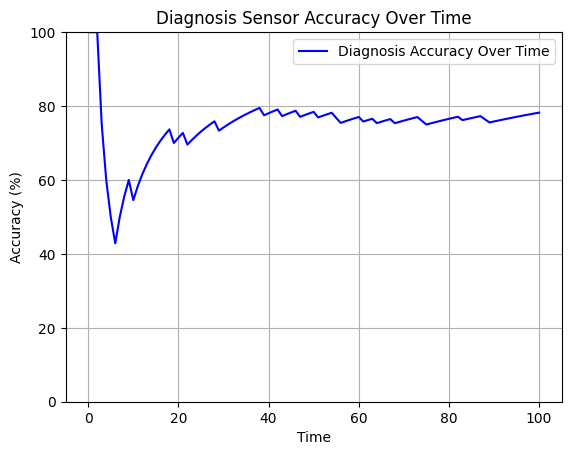

In [1]:
from sensor_objects.DiagnosisSensor import DiagnosisSensor
from component_objects.component_exponential import ExponentialComponent

import numpy as np
import matplotlib.pyplot as plt

num_time_steps = 100

comp = ExponentialComponent("basic component", MTTF=5, MTTR=2)
comp.simulate(num_time_steps)

# print(type(comp.history[5,1]))

sensor = DiagnosisSensor("basic diagnosis sensor", comp)
sensed_states = np.zeros(num_time_steps+1, dtype=int)
for i in range(num_time_steps+1):
    sensor.observation_matrix(i)
    sensed_states[i] = sensor.sensorLogic(int(comp.history[i,1]), i)

# plot true vs sensed states
# plt.plot(comp.history[:,0], sensed_states, 'ks', markersize= 10,  label="Diagnosed Component State")
# comp.plot_history()

# calculate the accuracy
correct_diagnoses = np.sum(sensed_states == comp.history[:,1])
accuracy = correct_diagnoses / (num_time_steps + 1) * 100
print(f"Diagnosis Sensor Accuracy: {accuracy:.2f}%")

# plot accuracy over time
accuracy_over_time = np.cumsum(sensed_states == comp.history[:,1]) / (np.arange(num_time_steps + 1) + 1) * 100
plt.figure()
plt.plot(comp.history[:,0], accuracy_over_time, 'b-', label="Diagnosis Accuracy Over Time")
plt.xlabel("Time")
plt.ylabel("Accuracy (%)")
plt.title("Diagnosis Sensor Accuracy Over Time")
plt.ylim(0, 100)
plt.grid()
plt.legend()
plt.show()

Text(0, 0.5, 'Bounded Exponential Value')

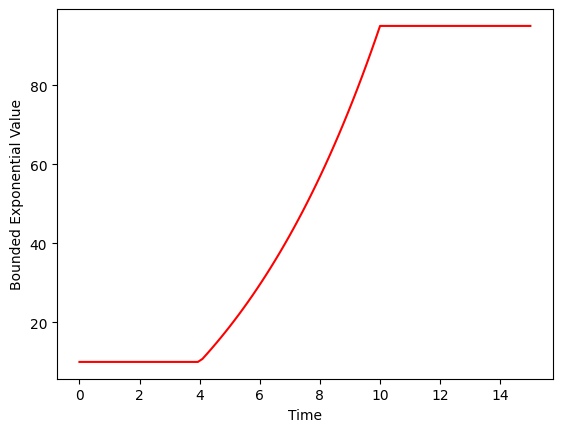

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def bounded_exponential(
    t: float,
    t0: float,
    tf: float,
    min_value: float,
    max_value: float
) -> float:
    """
    Exponential growth from min_value to max_value
    starting at t0 and ending at tf.
    """

    if t <= t0:
        return min_value

    if t >= tf:
        return max_value

    # Normalize time to [0, 1]
    tau = (t - t0) / (tf - t0)

    # Exponential curve normalized to hit endpoints exactly
    # exp(0) = 1 → min_value
    # exp(1) normalized → max_value
    growth = (np.exp(tau) - 1) / (np.e - 1)

    return min_value + growth * (max_value - min_value)

plt.figure()
times = np.linspace(0, 15, num_time_steps)
t_0 = 4
t_f = 10
min_val = 10
max_val = 95
values = [bounded_exponential(t, t_0, t_f, min_val, max_val) for t in times]
plt.plot(times, values, 'r-')
plt.xlabel("Time")
plt.ylabel("Bounded Exponential Value")

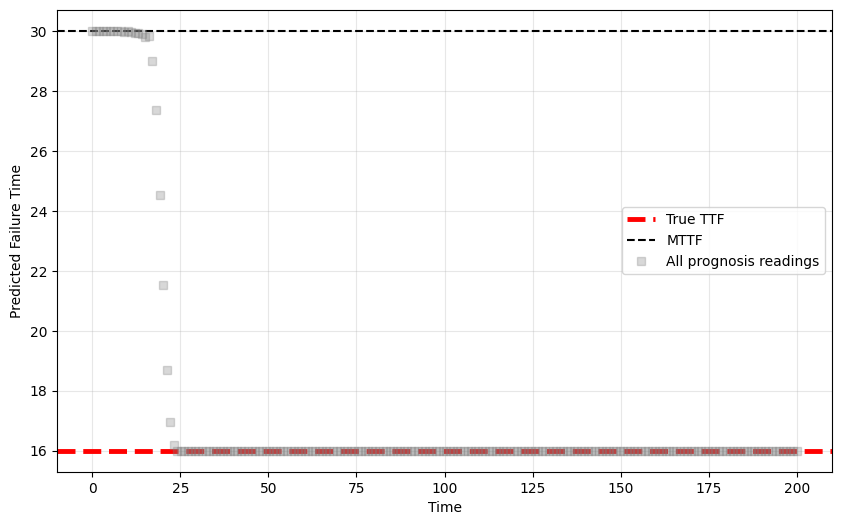

In [5]:
from sensor_objects.PrognosisSensor import PrognosisSensor
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt
import numpy as np

# initialize simulation parameters
comp_MTTF = 30
max_prob_predict_t_fail = 0.1
start_time = 0
end_time = 200
dt = 1
num_time_steps = int((end_time - start_time) / dt)
t_array = np.linspace(start_time, end_time, num_time_steps)

# initialize a component and prognosis sensor object
comp = ExponentialComponent("basic component", comp_MTTF, MTTR=2)
sensor = PrognosisSensor("basic prognosis sensor", comp, prob_predict_t_fail = max_prob_predict_t_fail)

# generate sensor predictions of comp TTF over time
sensor_prognosis = np.zeros_like(t_array)
for i,t in enumerate(t_array):
    sensor_prognosis[i] = sensor.sensorLogic(t)
    
# Create Figure
plt.figure(figsize=(10, 6))

# Add Reference lines
plt.axhline(comp.time_to_failure, color='r', linestyle='--',linewidth = 3.5,  label='True TTF') # true comp TTF line
plt.axhline(comp.MTTF, color='k', linestyle='--', label='MTTF')                # MTTF line
# plt.plot(t_array, t_array, '--', color='black', alpha=0.4, label='y = t')      # y=x line

# Plot all predictions (faint background)
plt.plot(
    t_array,
    sensor_prognosis,
    's',
    color='gray',
    alpha=0.3,
    label='All prognosis readings'
)

plt.xlabel("Time")
plt.ylabel("Predicted Failure Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Adding diagnostic sensor readings to the prognostics sensor update

In [ ]:
# Determine which predictions are correct (within a given error tolerance)
tol = 1e-2
correct_mask = np.isclose(
    sensor_prognosis,
    comp.time_to_failure,
    rtol=tol
)

# Define the interval between MTTF and TTF (order-agnostic)
lower = min(comp.MTTF, comp.time_to_failure)
upper = max(comp.MTTF, comp.time_to_failure)
between_mask = (
    (t_array >= lower) &
    (t_array <= upper)
)

# Early wrong: predicts failure too late (optimistic)
early_wrong_mask = (
    between_mask &
    (~correct_mask) &
    (sensor_prognosis > comp.time_to_failure)
)

# Late wrong: predicts failure too early (pessimistic)
late_wrong_mask = (
    between_mask &
    (~correct_mask) &
    (sensor_prognosis < comp.time_to_failure)
)

# Create Figure
plt.figure(figsize=(10, 6))

# Add Reference lines
plt.axhline(comp.time_to_failure, color='k', linestyle='--',linewidth = 5,  label='True TTF') # true comp TTF line
plt.axhline(comp.MTTF, color='k', linestyle='--', label='MTTF')                # MTTF line
plt.plot(t_array, t_array, '--', color='black', alpha=0.4, label='y = t')      # y=x line

# Plot all predictions (faint background)
plt.plot(
    t_array,
    sensor_prognosis,
    's',
    color='gray',
    alpha=0.3,
    label='All prognosis readings'
)

# # Highlight the readings inbetween expected MTTF and TTF
# plt.plot(
#     t_array[between_mask], 
#     sensor_prognosis[between_mask], 
#     '.r', 
#     label= "Steps Until Prediction Corrects Itself"
# )

# # Highlight Early wrong (red)
# plt.plot(
#     t_array[early_wrong_mask],
#     sensor_prognosis[early_wrong_mask],
#     '.r',
#     label='Early wrong (too optimistic)'
# )

# # Highlight Late wrong (blue)
# plt.plot(
#     t_array[late_wrong_mask],
#     sensor_prognosis[late_wrong_mask],
#     '.b',
#     label='Late wrong (too pessimistic)'
# )

# # Correct predictions (black)
# plt.plot(
#     t_array[correct_mask],
#     sensor_prognosis[correct_mask],
#     'og',
#     label='Correct (within tolerance)'
# )


Trying a Particle Filter Prognosis Sensor

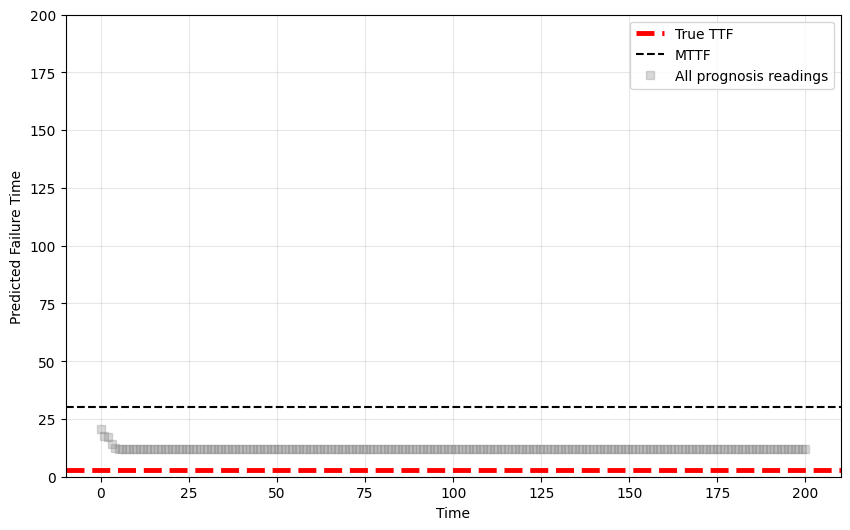

In [20]:
from sensor_objects.PF_PrognosisSensor import PF_PrognosisSensor
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt
import numpy as np

# initialize simulation parameters
comp_MTTF = 30
sensor_skill = 0.99
start_time = 0
end_time = 200
dt = 1
num_time_steps = int((end_time - start_time) / dt)
t_array = np.linspace(start_time, end_time, num_time_steps)

# initialize a component and prognosis sensor object
comp = ExponentialComponent("basic component", comp_MTTF, MTTR=2)
sensor = PF_PrognosisSensor("basic prognosis sensor", comp, sensor_skill = sensor_skill)

# generate sensor predictions of comp TTF over time
sensor_prognosis = np.zeros_like(t_array)
for i,t in enumerate(t_array):
    sensor_prognosis[i] = sensor.sensorLogic(t)
    
# Create Figure
plt.figure(figsize=(10, 6))

# Add Reference lines
plt.axhline(comp.time_to_failure, color='r', linestyle='--',linewidth = 3.5,  label='True TTF') # true comp TTF line
plt.axhline(comp.MTTF, color='k', linestyle='--', label='MTTF')                # MTTF line
# plt.plot(t_array, t_array, '--', color='black', alpha=0.4, label='y = t')      # y=x line

# Plot all predictions (faint background)
plt.plot(
    t_array,
    sensor_prognosis,
    's',
    color='gray',
    alpha=0.3,
    label='All prognosis readings'
)

plt.xlabel("Time")
plt.ylabel("Predicted Failure Time")
plt.ylim((0,200))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [3]:
from sensor_objects.PF_PrognosisSensor import PF_PrognosisSensor
from component_objects.component_exponential import ExponentialComponent

import numpy as np


def evaluate_pf_sensor_accuracy(
    N_components: int = 100,
    comp_MTTF: float = 30.0,
    sensor_skill: float = 0.99,
    start_time: float = 0.0,
    end_time: float = 200.0,
    dt: float = 1.0,
    tolerance_frac: float = 0.1,   # ±10% of true TTF
    verbose: bool = False
):
    """
    Monte Carlo evaluation of PF prognosis sensor accuracy.
    """

    num_time_steps = int((end_time - start_time) / dt)
    t_array = np.linspace(start_time, end_time, num_time_steps)

    correct_predictions = 0
    final_errors = []

    for n in range(N_components):

        # ----------------------------------------------------------
        # Create component + sensor
        # ----------------------------------------------------------
        comp = ExponentialComponent(
            f"component_{n}",
            comp_MTTF,
            MTTR=2
        )

        sensor = PF_PrognosisSensor(
            f"pf_sensor_{n}",
            comp,
            sensor_skill=sensor_skill
        )

        # ----------------------------------------------------------
        # Run simulation
        # ----------------------------------------------------------
        for t in t_array:
            sensor.sensorLogic(t)

        # ----------------------------------------------------------
        # Final prediction check
        # ----------------------------------------------------------
        tf_true = comp.time_to_failure
        tf_est = sensor.sensorLogic(t_array[-1])

        error = abs(tf_est - tf_true)
        final_errors.append(error)

        tolerance = tolerance_frac * tf_true
        if error <= tolerance:
            correct_predictions += 1

        if verbose:
            print(
                f"[{n}] True TTF={tf_true:.2f}, "
                f"Pred={tf_est:.2f}, "
                f"Error={error:.2f}"
            )

    # --------------------------------------------------------------
    # Metrics
    # --------------------------------------------------------------
    accuracy = correct_predictions / N_components * 100.0

    return {
        "accuracy_percent": accuracy,
        "mean_abs_error": np.mean(final_errors),
        "median_abs_error": np.median(final_errors),
        "errors": np.array(final_errors)
    }


results = evaluate_pf_sensor_accuracy(
    N_components=200,
    comp_MTTF=30,
    sensor_skill=0.99,
    tolerance_frac=0.1
)

print(f"Accuracy: {results['accuracy_percent']:.1f}%")
print(f"Mean abs error: {results['mean_abs_error']:.2f}")
print(f"Median abs error: {results['median_abs_error']:.2f}")



Accuracy: 85.0%
Mean abs error: 1.12
Median abs error: 0.79


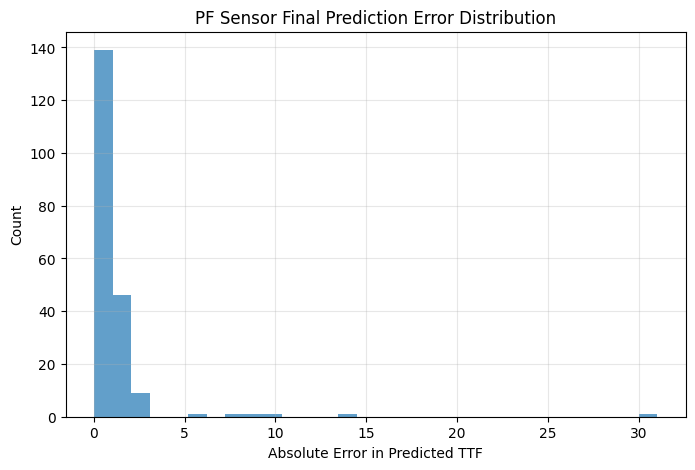

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(results["errors"], bins=30, alpha=0.7)
plt.xlabel("Absolute Error in Predicted TTF")
plt.ylabel("Count")
plt.title("PF Sensor Final Prediction Error Distribution")
plt.grid(alpha=0.3)
plt.show()